**Part1-Feed forward neural network**





In [1]:

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

print("Input:")
print(X)

print("Output:")
print(y)

Input:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
Output:
[0 1 1 0]


In [3]:
model = Sequential([
    Dense(8, activation="relu", input_shape=(2,)),
    Dense(4, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6811
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.6799
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.6786
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.6773
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2500 - loss: 0.6761
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2500 - loss: 0.6748
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2500 - loss: 0.6736
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.6724
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2500 - loss: 0.6711
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2500 - loss: 0.6699
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2500 - loss: 0.6687
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2500 - loss

In [6]:
loss, accuracy = model.evaluate(X, y, verbose=0)

print("Loss:", loss)
print("Accuracy:", accuracy * 100, "%")

Loss: 0.601764440536499
Accuracy: 75.0 %


In [7]:
predictions = model.predict(X)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.52287734]
 [0.52283984]
 [0.5227899 ]
 [0.30927974]]


In [8]:
predicted_classes = (predictions > 0.5).astype(int)

print(predicted_classes)

[[1]
 [1]
 [1]
 [0]]


In [9]:
import matplotlib.pyplot as plt

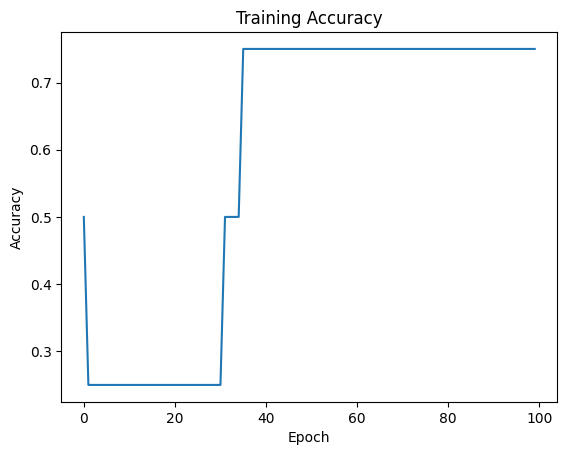

In [10]:
plt.plot(history.history["accuracy"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

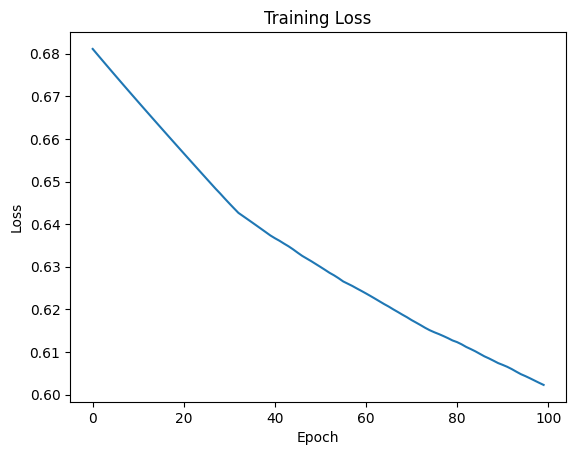

In [11]:
plt.plot(history.history["loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**PART 2 – CNN IMAGE CLASSIFIER**




In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers, models

In [13]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 741s 4us/step
Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [14]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

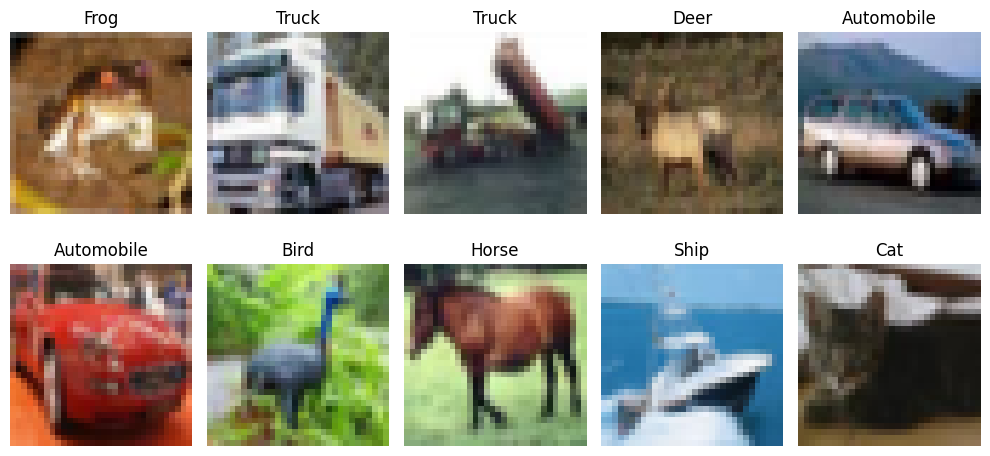

In [15]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [18]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.4442 - loss: 1.5441 - val_accuracy: 0.5252 - val_loss: 1.3451
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.5727 - loss: 1.2118 - val_accuracy: 0.6015 - val_loss: 1.1377
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.6241 - loss: 1.0775 - val_accuracy: 0.6280 - val_loss: 1.0789
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.6545 - loss: 0.9913 - val_accuracy: 0.6562 - val_loss: 1.0007
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.6779 - loss: 0.9296 - val_accuracy: 0.6654 - val_loss: 0.9839
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.6977 - loss: 0.8744 - val_accuracy: 0.6652 - val_loss: 0.9721
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.7143 - loss: 0.8245 - val_accuracy: 0.6830 - val_loss: 0.9342
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.7318 - loss: 0.7757 - 

In [22]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", test_accuracy * 100, "%")
print("Test Loss:", test_loss)

Test Accuracy: 67.00999736785889 %
Test Loss: 0.9699357151985168


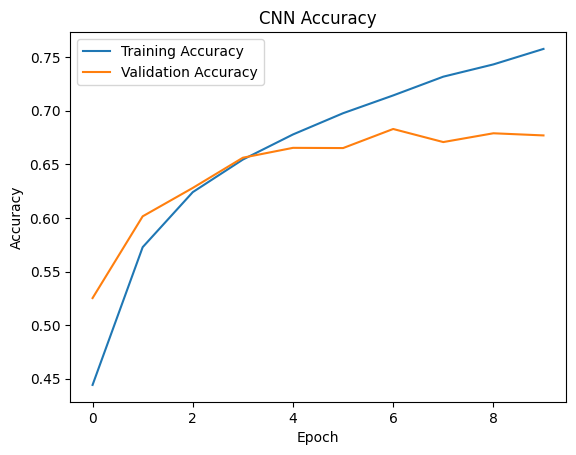

In [23]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

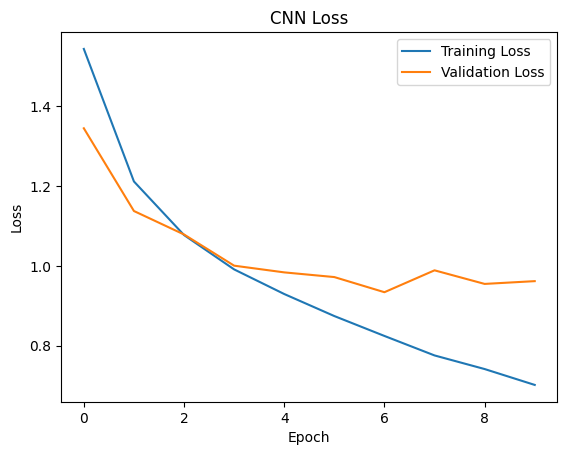

In [24]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

**Part3-Hyperparameter Experiment**

In [35]:
model_exp2 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_exp2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_exp2 = model_exp2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

loss_exp2, accuracy_exp2 = model_exp2.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Experiment 2 Accuracy:", accuracy_exp2 * 100, "%")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 74ms/step - accuracy: 0.4124 - loss: 1.6264 - val_accuracy: 0.5070 - val_loss: 1.4009
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - accuracy: 0.5378 - loss: 1.3003 - val_accuracy: 0.5564 - val_loss: 1.2531
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.5922 - loss: 1.1599 - val_accuracy: 0.6016 - val_loss: 1.1408
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - accuracy: 0.6336 - loss: 1.0518 - val_accuracy: 0.6196 - val_loss: 1.0877
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.6556 - loss: 0.9852 - val_accuracy: 0.6419 - val_loss: 1.0407
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 73ms/step - accuracy: 0.6776 - loss: 0.9246 - val_accuracy: 0.6535 - val_loss: 0.9990
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.6955 - loss: 0.8763 - val_accuracy: 0.6676 - val_loss: 0.9682
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.7072 - loss: 0.8369 - 

In [36]:
model_exp3 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [37]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model_exp3.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history_exp3 = model_exp3.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.3192 - loss: 1.9250 - val_accuracy: 0.4008 - val_loss: 1.6893
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 80ms/step - accuracy: 0.4326 - loss: 1.5912 - val_accuracy: 0.4528 - val_loss: 1.5355
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 73ms/step - accuracy: 0.4780 - loss: 1.4687 - val_accuracy: 0.4863 - val_loss: 1.4588
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - accuracy: 0.5065 - loss: 1.3965 - val_accuracy: 0.5109 - val_loss: 1.3911
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.5258 - loss: 1.3463 - val_accuracy: 0.5358 - val_loss: 1.3376


In [39]:
loss_exp3, accuracy_exp3 = model_exp3.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Experiment 3 Accuracy:", accuracy_exp3 * 100, "%")

Experiment 3 Accuracy: 53.8100004196167 %


In [40]:
model_exp4 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [41]:
model_exp4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [42]:
history_exp4 = model_exp4.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 40ms/step - accuracy: 0.4553 - loss: 1.5154 - val_accuracy: 0.5613 - val_loss: 1.2505
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 49s 39ms/step - accuracy: 0.5867 - loss: 1.1689 - val_accuracy: 0.6073 - val_loss: 1.1164
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 41ms/step - accuracy: 0.6346 - loss: 1.0442 - val_accuracy: 0.6070 - val_loss: 1.1472
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.6636 - loss: 0.9662 - val_accuracy: 0.6624 - val_loss: 0.9921
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.6859 - loss: 0.9039 - val_accuracy: 0.6542 - val_loss: 1.0032


In [43]:
loss_exp4, accuracy_exp4 = model_exp4.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Experiment 4 Accuracy:", accuracy_exp4 * 100, "%")

Experiment 4 Accuracy: 65.72999954223633 %
